## Time Series Analysis
Dataset: Stock Price Dataset

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

df = pd.read_csv('stock_data.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)
df = df.sort_index()
df.head()

,Open,High,Low,Close,Volume,Name
Date,,,,,,
2006-01-03,39.69,41.22,38.79,40.91,24232729,AABA
2006-01-04,41.22,41.90,40.77,40.97,20553479,AABA
2006-01-05,40.93,41.73,40.85,41.53,12829610,AABA
2006-01-06,42.88,43.57,42.80,43.21,29422828,AABA
2006-01-09,43.10,43.66,42.82,43.42,16268338,AABA


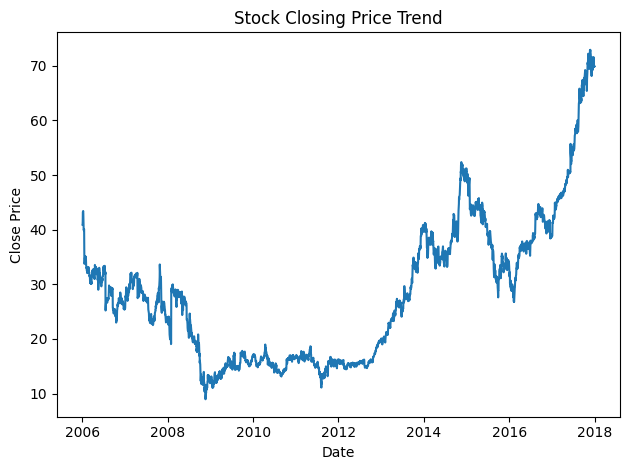

In [4]:
plt.figure()
plt.plot(df['Close'])
plt.title("Stock Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.tight_layout()
plt.show()

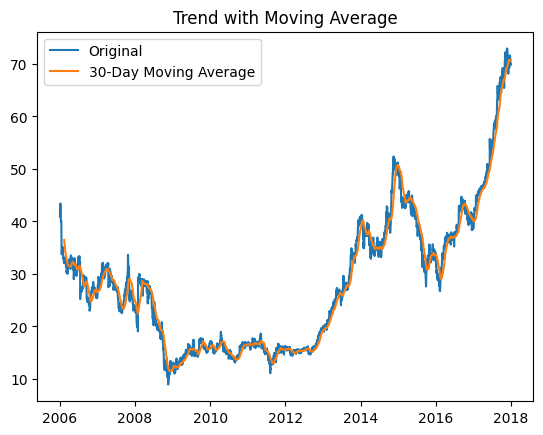

In [5]:
df['MA_30'] = df['Close'].rolling(window=30).mean()

plt.figure()
plt.plot(df['Close'], label='Original')
plt.plot(df['MA_30'], label='30-Day Moving Average')
plt.legend()
plt.title("Trend with Moving Average")
plt.show()


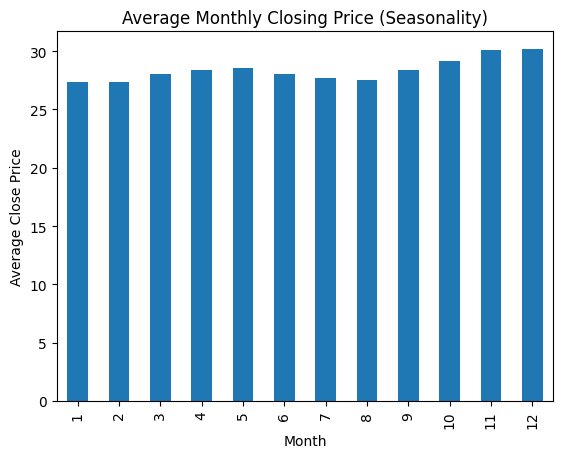

In [6]:
df['Month'] = df.index.month

monthly_avg = df.groupby('Month')['Close'].mean()

plt.figure()
monthly_avg.plot(kind='bar')
plt.title("Average Monthly Closing Price (Seasonality)")
plt.xlabel("Month")
plt.ylabel("Average Close Price")
plt.show()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/p

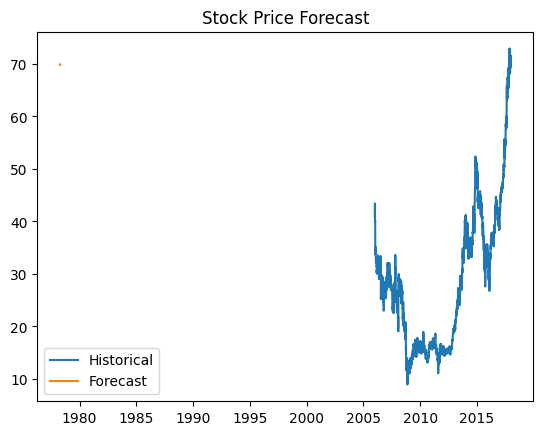

In [12]:

# -------------------------------
# 4. OPTIONAL: FORECASTING
# -------------------------------
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(df['Close'], order=(5,1,0))
model_fit = model.fit()

# Forecast next 10 days
forecast = model_fit.forecast(steps=10)

# Plot forecast
plt.figure()
plt.plot(df['Close'], label='Historical')
plt.plot(forecast, label='Forecast')
plt.legend()
plt.title("Stock Price Forecast")
plt.show()


In [9]:
print("Trend Insight: Overall direction visible from line chart.")
print("Seasonality Insight: Monthly variation shows repeating patterns.")
print("Forecast Insight: Predicted next 10 days based on ARIMA model.")

Trend Insight: Overall direction visible from line chart.
Seasonality Insight: Monthly variation shows repeating patterns.
Forecast Insight: Predicted next 10 days based on ARIMA model.
